In [9]:
import pandas as pd
import lightgbm as lgb
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# 1. 복잡한 도구 말고, 원본 엑셀 파일만 딱 하나 가져옵니다!
df = pd.read_csv('../data/최종_전처리완료.csv', encoding='cp949')
df.columns = df.columns.str.strip()

for col in X_cols:
    if df[col].dtype == 'object': # 만약 숫자가 아니라 글자(object)로 되어있다면
        # 쉼표(,)를 지우고 진짜 숫자(float)로 바꿔라!
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)


y_col = '개선 인구 소멸 지수'
X_cols = [
    '고용률', '노인여가복지시설수', '초등학교 학생수 (명)', '가구수 (가구)', 
    '도소매업 사업체수(등록기반) (개)', '도소매업 종사자수(등록기반) (명)', 
    '서비스업 사업체수(등록기반) (개)', '평균연령 (세)', '유치원 교원수 (명)', 
    '혼인건수 (건)', '학급당 학생수 (명)', '출생아수 (명)', '신혼부부수 (쌍)', 
    '제조업 사업체수(등록기반) (개)', '인구총조사 인구 (명)', '주민등록인구 (명)', 
    '하수도보급률 (%)', '노인인구 1000명 당 여가복지시설', 
    '운수업 종사자수(등록기반) (명)', '초등학교 교원수 (명)', 
    '조혼인율 (천명당)', '이혼건수 (건)', '유치원 원아수 (명)'
]

# 2. 2023년까지 공부할 내용과 2024년 시험 볼 내용 나누기
train_df = df[df['year'] <= 2023].dropna(subset=[y_col])
val_df = df[df['year'] == 2024].dropna(subset=[y_col])

X_train = train_df[X_cols]
y_train = train_df[y_col]
X_val = val_df[X_cols]
y_val = val_df[y_col]

# 3. 로봇 다시 공부시키고 2024년 시험 보기
lgbm = lgb.LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)
y_pred_val = lgbm.predict(X_val)

# 4. LightGBM (y값) 성적표 대공개!
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mse = mean_squared_error(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)
mape = mean_absolute_percentage_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print("=== 🏆 y값 (LightGBM) 2024년 예측 성적표 ===")
print(f'RMSE (오차 크기): {rmse:.4f}')
print(f'MSE (오차 제곱): {mse:.4f}')
print(f'MAE (평균 오차): {mae:.4f}')
print(f'MAPE (오차율 %): {mape:.4f}')
print(f'R^2 Score (설명력): {r2:.4f}')

# 5. 사장님이 찾으시던 통계(p-value) 표
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm)
ols_result = ols_model.fit()
print("\n" + "="*50)
print("통계적 분석표 (OLS Summary)")
print("="*50)
print(ols_result.summary())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5526
[LightGBM] [Info] Number of data points in the train set: 916, number of used features: 23
[LightGBM] [Info] Start training from score 1.464105
=== 🏆 y값 (LightGBM) 2024년 예측 성적표 ===
RMSE (오차 크기): 0.1089
MSE (오차 제곱): 0.0119
MAE (평균 오차): 0.0600
MAPE (오차율 %): 0.0397
R^2 Score (설명력): 0.9045

통계적 분석표 (OLS Summary)
                            OLS Regression Results                            
Dep. Variable:            개선 인구 소멸 지수   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     174.3
Date:                Wed, 25 Feb 2026   Prob (F-statistic):          7.50e-311
Time:              

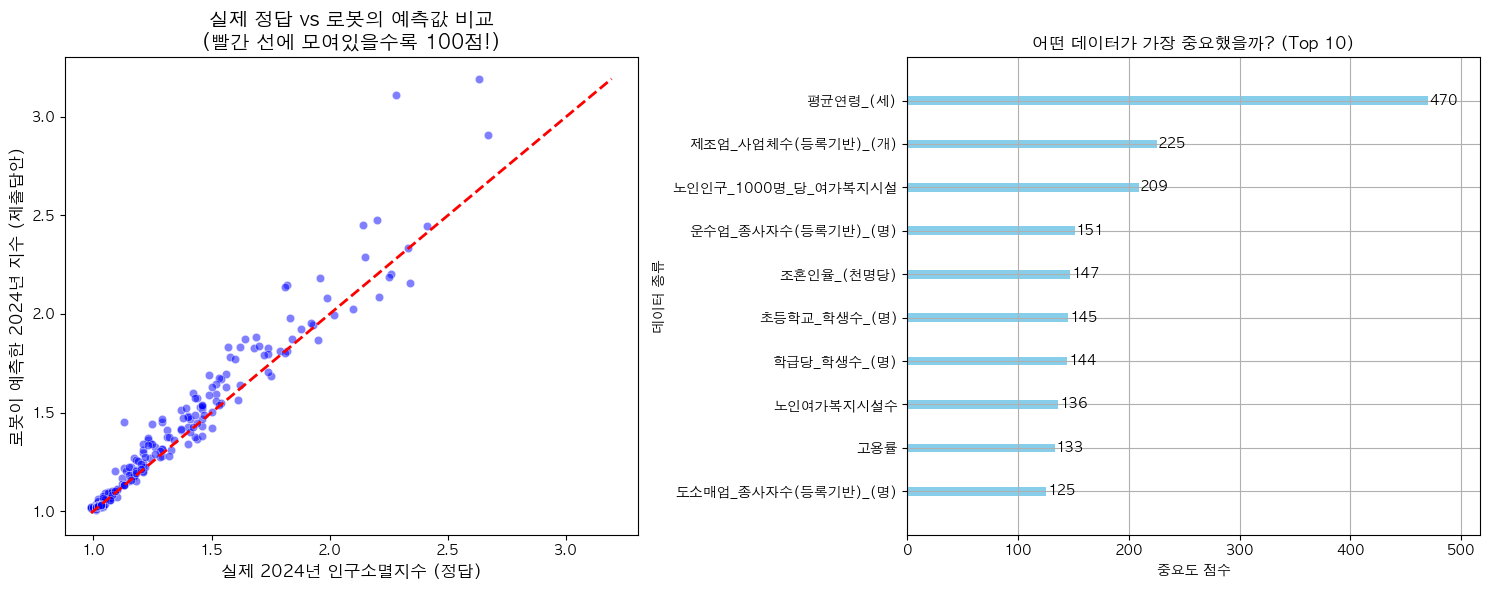

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

# 🍎 맥북용 한글 폰트 설정 (만약 윈도우시면 'Malgun Gothic'으로 바꿔주세요!)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 그래프 그릴 도화지 준비 (가로로 두 개 나란히)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------------------------------------------------
# 📊 1. 진짜 정답 vs 로봇의 예측값 비교 그래프 (얼마나 잘 맞췄나?)
# -------------------------------------------------------------------
sns.scatterplot(x=y_val, y=y_pred_val, ax=ax[0], color='blue', alpha=0.5)

# 완벽하게 맞췄을 때의 기준선(빨간 대각선) 그리기
min_val = min(y_val.min(), y_pred_val.min())
max_val = max(y_val.max(), y_pred_val.max())
ax[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

ax[0].set_title('실제 정답 vs 로봇의 예측값 비교\n(빨간 선에 모여있을수록 100점!)', fontsize=14)
ax[0].set_xlabel('실제 2024년 인구소멸지수 (정답)', fontsize=12)
ax[0].set_ylabel('로봇이 예측한 2024년 지수 (제출답안)', fontsize=12)

# -------------------------------------------------------------------
# 📈 2. 변수 중요도 (어떤 힌트가 가장 쓸모 있었나?)
# -------------------------------------------------------------------
# 로봇아, 네가 푼 문제 중에서 어떤 데이터가 제일 중요했는지 10개만 보여줘!
lgb.plot_importance(lgbm, max_num_features=10, ax=ax[1], color='skyblue', title='어떤 데이터가 가장 중요했을까? (Top 10)')
ax[1].set_xlabel('중요도 점수')
ax[1].set_ylabel('데이터 종류')

# 그림 짠! 하고 보여주기
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# 만약 모듈이 없다고 에러가 나면 터미널에: pip install pmdarima
from pmdarima import auto_arima

print("🤖 아리마 로봇이 23개 과목(X값) 모의고사를 봅니다! 시간이 조금 걸릴 수 있어요...")

# 1. 2023년까지의 데이터와 2024년 진짜 정답 나누기
df_train = df[df['year'] <= 2023]
df_test = df[df['year'] == 2024]

results = []

# 2. 23개의 과목을 하나씩 돌면서 시험 보기!
for col in X_cols:
    try:
        # 각 과목별로 연도순으로 데이터 정리
        y_train_series = df_train.groupby('year')[col].mean() # 전국 평균으로 시험 본다고 가정!
        y_test_true = df_test[col].mean()
        
        # 아리마 로봇 공부시키기 (알아서 제일 좋은 설정값을 찾음!)
        model = auto_arima(y_train_series, seasonal=False, suppress_warnings=True)
        
        # 2024년 딱 1년치만 예측해봐!
        pred_2024 = model.predict(n_periods=1).iloc[0]
        
        # 오차율 계산
        mape = np.abs((y_test_true - pred_2024) / y_test_true) * 100
        
        results.append({
            '과목명(데이터)': col, 
            '실제 정답': round(y_test_true, 2),
            '로봇 예측값': round(pred_2024, 2),
            '오차율(%)': round(mape, 2)
        })
        print(f"✅ {col} 시험 완료! (오차율: {mape:.2f}%)")
        
    except Exception as e:
        print(f"❌ {col} 시험 중 문제 발생: {e}")

# 3. 성적표 예쁘게 출력하기
error_df = pd.DataFrame(results).sort_values(by='오차율(%)').reset_index(drop=True)

print("\n=== 🏆 ARIMA 로봇 2024년 모의고사 최종 성적표 ===")
print("오차율(%)이 낮을수록 100점에 가깝게 맞춘 겁니다!\n")
print(error_df.to_string())

🤖 아리마 로봇이 23개 과목(X값) 모의고사를 봅니다! 시간이 조금 걸릴 수 있어요...
✅ 고용률 시험 완료! (오차율: 2.73%)
✅ 노인여가복지시설수 시험 완료! (오차율: 1.90%)
✅ 초등학교 학생수 (명) 시험 완료! (오차율: 6.55%)
✅ 가구수 (가구) 시험 완료! (오차율: 3.66%)
✅ 도소매업 사업체수(등록기반) (개) 시험 완료! (오차율: 1.69%)
✅ 도소매업 종사자수(등록기반) (명) 시험 완료! (오차율: 1.47%)
✅ 서비스업 사업체수(등록기반) (개) 시험 완료! (오차율: 0.75%)
✅ 평균연령 (세) 시험 완료! (오차율: 2.82%)
✅ 유치원 교원수 (명) 시험 완료! (오차율: 2.05%)
✅ 혼인건수 (건) 시험 완료! (오차율: 13.19%)
✅ 학급당 학생수 (명) 시험 완료! (오차율: 4.01%)
✅ 출생아수 (명) 시험 완료! (오차율: 8.52%)
✅ 신혼부부수 (쌍) 시험 완료! (오차율: 12.70%)
✅ 제조업 사업체수(등록기반) (개) 시험 완료! (오차율: 6.16%)
✅ 인구총조사 인구 (명) 시험 완료! (오차율: 0.06%)
✅ 주민등록인구 (명) 시험 완료! (오차율: 0.67%)
✅ 하수도보급률 (%) 시험 완료! (오차율: 1.40%)
✅ 노인인구 1000명 당 여가복지시설 시험 완료! (오차율: 6.84%)
✅ 운수업 종사자수(등록기반) (명) 시험 완료! (오차율: 3.69%)
✅ 초등학교 교원수 (명) 시험 완료! (오차율: 2.00%)
✅ 조혼인율 (천명당) 시험 완료! (오차율: 9.85%)
✅ 이혼건수 (건) 시험 완료! (오차율: 3.53%)
✅ 유치원 원아수 (명) 시험 완료! (오차율: 13.80%)

=== 🏆 ARIMA 로봇 2024년 모의고사 최종 성적표 ===
오차율(%)이 낮을수록 100점에 가깝게 맞춘 겁니다!

               과목명(데이터)      실제 정답     로봇 예측값  오차율(%)
0          인구총조사 인구 (